# Random Forest v2

Von Claude:
### Warum *nicht* nur Random Forest?
Random Forest ist ein solider Baseline – aber für hochdimensionale Genomdaten (~16k Features, ~1000 Samples) zeigt die Literatur konsistent, dass **Logistic Regression mit ElasticNet-Regularisierung** (L1+L2) und **XGBoost** besser abschneiden:

| Modell | Stärke bei Genomdaten | Typische Accuracy (TCGA BRCA) |
|---|---|---|
| Random Forest | Robust, kein Scaling nötig | ~93–95 % |
| **Logistic Reg. (ElasticNet)** | Sparsity, interpretierbar, skaliert gut mit vielen Features | **~95–97 %** |
| **XGBoost** | Tabular SOTA, robust gegen Imbalance | **~95–96 %** |
| LinearSVC | Schnell, gut bei linearer Separierbarkeit | ~94–96 % |

Wir testen alle vier und wählen den Gewinner mit Nested CV.

## 1) Packages installieren & importieren

In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib #um model zu speichern
import warnings
warnings.filterwarnings("ignore")

# Sklearn
from sklearn.model_selection import(train_test_split, 
                                    StratifiedKFold, 
                                    cross_val_score, 
                                    RandomizedSearchCV, 
                                    cross_validate, 
                                    cross_val_predict
                                    )
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, f1_score)
from sklearn.decomposition import PCA

#XGBoost
import xgboost
from xgboost import XGBClassifier

#UMAP (für bessere Visualisierung als PCA)
try:
    from umap import UMAP
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP ist nicht installiert. nur PCA wird verwendet. Für UMAP 'pip install umap-learn' verwenden.")

#Seed für Reproduzierbarkeit
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Alle Pakete erfolgreich importiert.")


Alle Pakete erfolgreich importiert.


## 2) Datensätze laden & kombinieren

In [35]:
os.chdir(r"C:\Users\niels\OneDrive\ETH\FS26\Foundations of Data Science\Group Project\TCGA")

df      = pd.read_csv("dataset.csv", index_col=0)
outcome = pd.read_csv("outcome.csv", index_col=0)
outcome.columns = ["BRCA_subtype"]

#Datensätze verbinden
combined = df.join(outcome)

print(f"Dataset: {df.shape[0]} Samples (Patientinnen) x {df.shape[1]} Features (Gene mit zugehöriger Expression)")
print(f"Outcome: {outcome.shape[0]} Samples (Patientinnen mit zugehörigem BRCA-Subtyp))")
print(f"Combined Dataset: {combined.shape[0]} Samples (Patientinnen) x {combined.shape[1]} Features (Gene + BRCA-Subtyp))")
print(f"Patientinnen ohne Subtyp-Label: {combined['BRCA_subtype'].isna().sum()} (werden für Training/Testing ignoriert)")
print("\nKlassenverteilung (komplett):")
print(combined['BRCA_subtype'].value_counts())

Dataset: 1218 Samples (Patientinnen) x 16383 Features (Gene mit zugehöriger Expression)
Outcome: 1218 Samples (Patientinnen mit zugehörigem BRCA-Subtyp))
Combined Dataset: 1218 Samples (Patientinnen) x 16384 Features (Gene + BRCA-Subtyp))
Patientinnen ohne Subtyp-Label: 262 (werden für Training/Testing ignoriert)

Klassenverteilung (komplett):
BRCA_subtype
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64


## 3) Daten bereinigen

### 3.1 Samples ohne Label (Subtyp) entfernen

In [36]:
combined_clean = combined.dropna(subset=['BRCA_subtype']).copy()
print(f"Samples nach Entfernen von Patientinnen ohne Subtyp-Label: {combined_clean.shape[0]}")

X_raw = combined_clean.drop(columns=['BRCA_subtype'])
y = combined_clean['BRCA_subtype']

print(f"\nKlassenverteilung nach Entfernen von Patientinnen ohne Subtyp-Label:")
print(y.value_counts())


Samples nach Entfernen von Patientinnen ohne Subtyp-Label: 956

Klassenverteilung nach Entfernen von Patientinnen ohne Subtyp-Label:
BRCA_subtype
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64


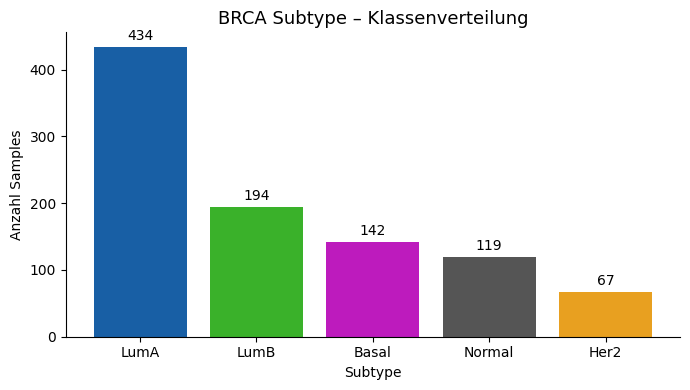


⚠️  Imbalance Ratio (LumA / Her2): 6.5x


In [37]:
# Klassenverteilung visualisieren
SUBTYPE_COLORS = {
    "LumA": "#185FA5", "LumB": "#3AB12A",
    "Basal": "#BD1BBD", "Her2": "#E8A020", "Normal": "#555555"
}

fig, ax = plt.subplots(figsize=(7, 4))
counts = y.value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[SUBTYPE_COLORS.get(s, "#888") for s in counts.index],
              edgecolor="none")
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title("BRCA Subtype – Klassenverteilung", fontsize=13)
ax.set_ylabel("Anzahl Samples")
ax.set_xlabel("Subtype")
sns.despine()
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

# Achtung: Klassen-Imbalance!
# LumA (434) >> Her2 (67) → class_weight='balanced' ist wichtig
print(f"\n⚠️  Imbalance Ratio (LumA / Her2): {counts['LumA'] / counts['Her2']:.1f}x")

### 3.2 NaN-Imputation in Features

In [38]:
nan_count = X_raw.isna().sum().sum()
print(f"Anzahl fehlender Werte in den Genexpressiondaten: {nan_count}")

combined_clean = combined_clean.dropna().copy()
print(f"Samples nach Entfernen von Patientinnen mit fehlenden Werten: {combined_clean.shape[0]}")

Anzahl fehlender Werte in den Genexpressiondaten: 6
Samples nach Entfernen von Patientinnen mit fehlenden Werten: 950


### 3.3 Zweistufige Feature-Selektion
**Schritt 1: Varianz-Filter:** Gene mit geringer Varianz entfernen (unter 10%)

**Schritt 2: Anova F-Score (SelectKBest)** Gene nach statistischer Trennkraft zwischen den Subtypen ranken und Top-K behalten. Besser als reiner Varianzfilter, weil er die Labels berücksichtigt.

In [39]:
# Schritt 1: Varianz-Filter
sel_var = VarianceThreshold(threshold=0.1)
X_var   = sel_var.fit_transform(combined_clean.drop(columns=['BRCA_subtype']), y)
cols_var = combined_clean.drop(columns=['BRCA_subtype']).columns[sel_var.get_support()]
print(f"Nach Varianz-Filter: {X_var.shape[1]} Gene (von {combined_clean.shape[1] - 1} ursprünglichen)")

# --- Schritt 2: ANOVA F-Score – Top 2000 Gene ---
K_BEST = 1000  # Sweet-Spot 2000: informativ, aber nicht zu viele für Overfitting
sel_k = SelectKBest(f_classif, k=K_BEST)
X_clean = combined_clean.drop(columns=['BRCA_subtype'])
y = combined_clean['BRCA_subtype']

sel_var = VarianceThreshold(threshold=0.1)
X_var = sel_var.fit_transform(X_clean, y)
cols_var = X_clean.columns[sel_var.get_support()]

sel_k = SelectKBest(f_classif, k=K_BEST)
X_k = sel_k.fit_transform(X_var, y)

# Spaltennamen wiederherstellen
sel_k_cols = cols_var[sel_k.get_support()]
X_selected = pd.DataFrame(X_k, index=combined_clean.index, columns=sel_k_cols)
print(f"Nach SelectKBest (k={K_BEST}): {X_selected.shape[1]} Gene")
print(f"\nTop 10 Gene nach ANOVA F-Score:")
f_scores = pd.Series(sel_k.scores_[sel_k.get_support()], index=sel_k_cols)
print(f_scores.sort_values(ascending=False).head(10))

Nach Varianz-Filter: 15222 Gene (von 16383 ursprünglichen)
Nach SelectKBest (k=1000): 1000 Gene

Top 10 Gene nach ANOVA F-Score:
ESR1       726.275771
MLPH       585.540419
FOXC1      584.459578
ROPN1      537.749820
FOXA1      486.117884
AGR3       482.940845
C6orf97    476.527376
TBC1D9     471.330139
SFRS13B    439.842289
TPX2       432.900267
dtype: float64


## 4) Splits erstellen

Stratified Split, damit die Klassenverteilung in beiden Sets gleich bleibt. besonders wichtig bei der Imbalance von Her2

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size = 0.2,
    random_state = RANDOM_STATE,
    stratify = y #makes sure, that all categories are present in training aswell as in test set, despite imbalance
)

print(f"Train: {X_train.shape[0]} Samples")
print(f"Test:  {X_test.shape[0]} Samples")
print(f"\nKlassenverteilung Train:\n{y_train.value_counts()}")
print(f"\nKlassenverteilung Test:\n{y_test.value_counts()}")

# Scaling (Standardisierung): wichtig für Logisitsche Regression & SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #fit NUR auf Trainingsdaten!
X_test_scaled = scaler.transform(X_test) #transform auf Testdaten
print("StandardScaler angewendet")

#LabelEncoder für CGBoost (benötigt Integer-Labels)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
print(f"Label-Mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Train: 760 Samples
Test:  190 Samples

Klassenverteilung Train:
BRCA_subtype
LumA      346
LumB      154
Basal     111
Normal     95
Her2       54
Name: count, dtype: int64

Klassenverteilung Test:
BRCA_subtype
LumA      87
LumB      38
Basal     28
Normal    24
Her2      13
Name: count, dtype: int64
StandardScaler angewendet
Label-Mapping: {'Basal': np.int64(0), 'Her2': np.int64(1), 'LumA': np.int64(2), 'LumB': np.int64(3), 'Normal': np.int64(4)}


## 5) Modell-Auswahl & Cross-Validation

**Strategie:** 5-Fold Stratified CV auf dem Traingsset, um die 4 Kandidaten fair zu vergleichen

Wir schauen auf **Accuracy** UND **Balanced Accuracy** (wichtig wegen Imbalance)

In [41]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

candidates = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": xgboost.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LogReg ElasticNet": LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=0.1,
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LinearSVC": CalibratedClassifierCV(
        LinearSVC(
            C=0.5,
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
}

cv_results = {}

print(
    f"{'Modell':<25}"
    f"{'Acc':>8}"
    f"{'BalAcc':>10}"
    f"{'Prec':>8}"
    f"{'Recall':>8}"
    f"{'F1':>8}"
    f"{'ROC_AUC':>10}"
)

print("-" * 80)

for name, model in candidates.items():

    # XGBoost braucht numerische Labels
    y_cv = y_train_encoded if name == "XGBoost" else y_train
    X_cv = X_train_scaled

    # ROC-AUC nur wenn predict_proba vorhanden
    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "precision": "precision_weighted",
        "recall": "recall_weighted",
        "f1": "f1_weighted"
    }

    if hasattr(model, "predict_proba"):
        scoring["roc_auc"] = "roc_auc_ovr_weighted"

    # Alle CV-Metriken in EINEM Durchlauf
    scores = cross_validate(
        model,
        X_cv,
        y_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    # Cross-validated predictions
    y_pred = cross_val_predict(
        model,
        X_cv,
        y_cv,
        cv=cv,
        n_jobs=-1
    )

    # Konfusionsmatrix
    cm = confusion_matrix(y_cv, y_pred)

    # Binärfall: TN FP FN TP extrahieren
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = None

    cv_results[name] = {
        "accuracy": scores["test_accuracy"],
        "balanced_accuracy": scores["test_balanced_accuracy"],
        "precision": scores["test_precision"],
        "recall": scores["test_recall"],
        "f1": scores["test_f1"],
        "confusion_matrix": cm,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn
    }

    if "test_roc_auc" in scores:
        cv_results[name]["roc_auc"] = scores["test_roc_auc"]
        roc_auc_mean = scores["test_roc_auc"].mean()
    else:
        roc_auc_mean = np.nan

    print(
        f"{name:<25}"
        f"{scores['test_accuracy'].mean():>8.3f}"
        f"{scores['test_balanced_accuracy'].mean():>10.3f}"
        f"{scores['test_precision'].mean():>8.3f}"
        f"{scores['test_recall'].mean():>8.3f}"
        f"{scores['test_f1'].mean():>8.3f}"
        f"{roc_auc_mean:>10.3f}"
    )

    if tp is not None:
        print(f"TP={tp}, FP={fp}, TN={tn}, FN={fn}") #gibt hier keine, da nur für binäre daten (ja/nein)

    print()

Modell                        Acc    BalAcc    Prec  Recall      F1   ROC_AUC
--------------------------------------------------------------------------------
Random Forest               0.893     0.862   0.898   0.893   0.891     0.987

XGBoost                     0.912     0.885   0.913   0.912   0.910     0.989

LogReg ElasticNet           0.912     0.913   0.917   0.912   0.913     0.989

LinearSVC                   0.854     0.809   0.859   0.854   0.851     0.970



Ergebnisse visualisieren

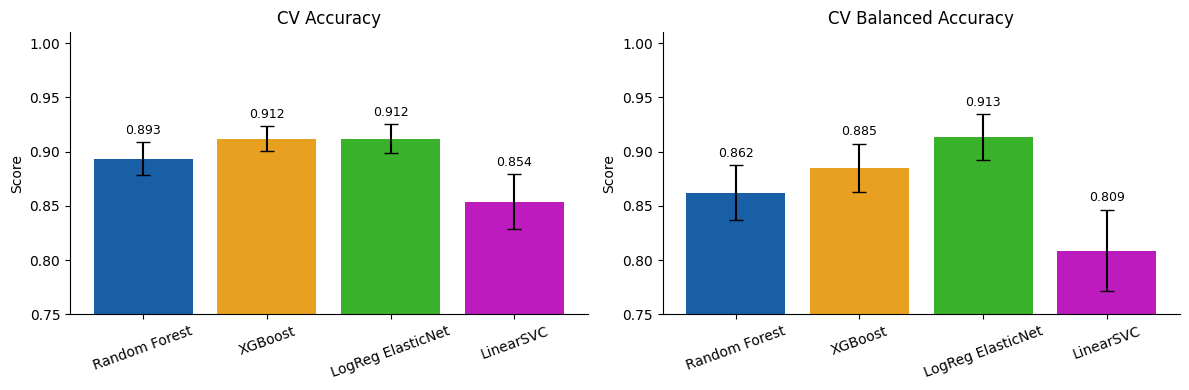

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics = ["accuracy", "balanced_accuracy"]
titles  = ["CV Accuracy", "CV Balanced Accuracy"]

for ax, metric, title in zip(axes, metrics, titles):
    means = [cv_results[n][metric].mean() for n in candidates]
    stds  = [cv_results[n][metric].std()  for n in candidates]
    bars  = ax.bar(candidates.keys(), means, yerr=stds,
                   capsize=5, color=["#185FA5","#E8A020","#3AB12A","#BD1BBD"],
                   edgecolor="none", error_kw={"linewidth":1.5})
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
    ax.set_ylim(0.75, 1.01)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=20)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("model_comparison_cv.png", dpi=150)
plt.show()

## 6) Hyperparameter-Tuning für bestes Modell

In [43]:
#für logistische Regression:
lr_cv = LogisticRegressionCV(
    Cs=np.logspace(-4, 2, 20),   # 1e-4 bis 1e2
    cv=cv,
    penalty="elasticnet",
    solver="saga",
    l1_ratios=np.linspace(0, 1, 11),
    scoring="balanced_accuracy",
    class_weight="balanced",
    max_iter=5000,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True
)

print("Starte LogRegCV...")

lr_cv.fit(X_train_scaled, y_train)

print("Bestes C:", lr_cv.C_[0])
print("Bestes l1_ratio:", lr_cv.l1_ratio_[0])

Starte LogRegCV...
Bestes C: 0.14384498882876628
Bestes l1_ratio: 0.1


## 7) Finales Modell trainieren

In [44]:
best_model = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    C=lr_cv.C_[0],
    l1_ratio=lr_cv.l1_ratio_[0],
    max_iter=5000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# Auf gesamtem Trainingsset trainieren
print("Trainiere finales Modell auf gesamtem Trainingsset...")
best_model.fit(X_train_scaled, y_train)

# Modell + gesamte Pipeline speichern
pipeline_artefakt = {
    "var_selector":   sel_var,
    "kbest_selector": sel_k,
    "scaler":         scaler,
    "label_encoder":  label_encoder,
    "model":          best_model,
}
joblib.dump(pipeline_artefakt, "TCGA_ML_v2.joblib")
print("✓ Pipeline gespeichert als 'TCGA_ML_v2.joblib'")

Trainiere finales Modell auf gesamtem Trainingsset...
✓ Pipeline gespeichert als 'TCGA_ML_v2.joblib'


## 8) Modell evaluieren
 Accuracy, balanced accuracy, Area under the curve sind wichtig

 (tp, fp, tn, fn, accuracy, precision, recall, f1, roc_auc) --> Notebook W9

In [45]:
# Predictions auf dem Hold-out Testset
y_pred_enc = best_model.predict(X_test_scaled)

acc     = accuracy_score(y_test, y_pred_enc)
bal_acc = balanced_accuracy_score(y_test, y_pred_enc)
macro_f1 = f1_score(y_test, y_pred_enc, average="macro")

print(f"=== Test-Set Ergebnisse ===")
print(f"Accuracy:          {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}  ← wichtiger wegen Imbalance")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"\n{classification_report(y_test, y_pred_enc)}")

=== Test-Set Ergebnisse ===
Accuracy:          0.8842
Balanced Accuracy: 0.8746  ← wichtiger wegen Imbalance
Macro F1:          0.8686

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.73      0.85      0.79        13
        LumA       0.92      0.90      0.91        87
        LumB       0.80      0.87      0.84        38
      Normal       0.91      0.83      0.87        24

    accuracy                           0.88       190
   macro avg       0.87      0.87      0.87       190
weighted avg       0.89      0.88      0.89       190



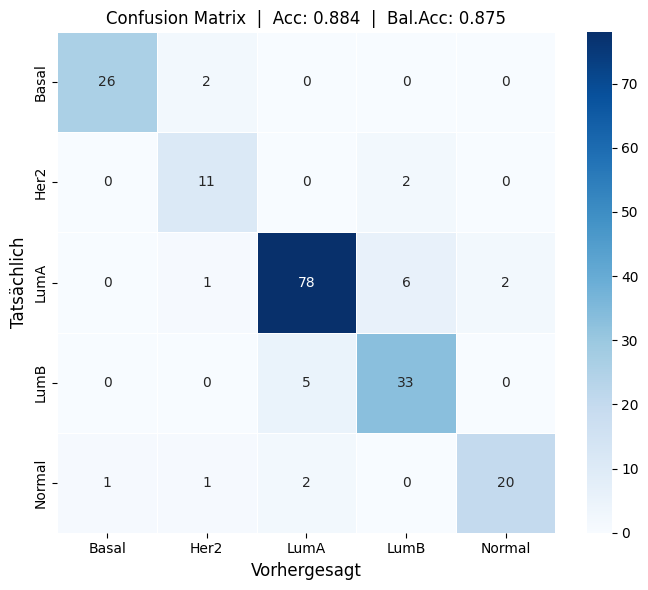

In [46]:
# Confusion Matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_enc, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, ax=ax
)
ax.set_xlabel("Vorhergesagt", fontsize=12)
ax.set_ylabel("Tatsächlich", fontsize=12)
ax.set_title(f"Confusion Matrix  |  Acc: {acc:.3f}  |  Bal.Acc: {bal_acc:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_v2.png", dpi=150)
plt.show()

        Precision  Recall  F1-Score  Support
Basal       0.963   0.929     0.945       28
Her2        0.733   0.846     0.786       13
LumA        0.918   0.897     0.907       87
LumB        0.805   0.868     0.835       38
Normal      0.909   0.833     0.870       24


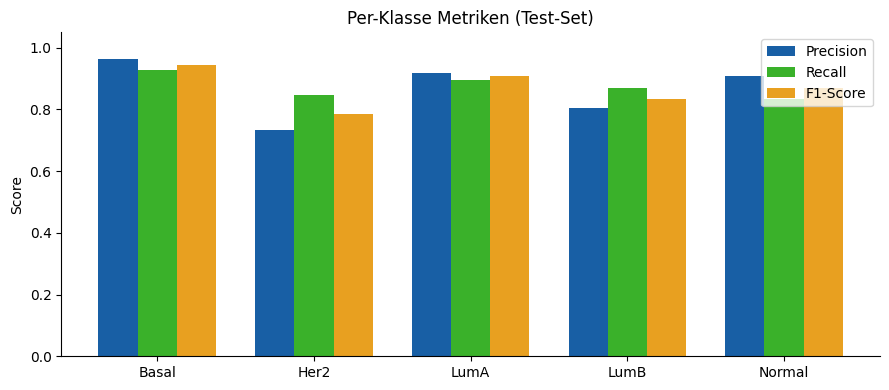

In [47]:
# Per-Klasse Precision / Recall / F1 visualisieren
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, support = precision_recall_fscore_support(y_test, y_pred_enc, labels=labels)
metrics_df = pd.DataFrame({
    "Precision": prec, "Recall": rec, "F1-Score": f1, "Support": support
}, index=labels)
print(metrics_df.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(labels))
w = 0.25
ax.bar(x - w,   prec, w, label="Precision", color="#185FA5")
ax.bar(x,       rec,  w, label="Recall",    color="#3AB12A")
ax.bar(x + w,   f1,   w, label="F1-Score",  color="#E8A020")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Klasse Metriken (Test-Set)")
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150)
plt.show()

Top 15 Gene (|Koeffizient| gemittelt über Klassen):
WDR67       0.100650
FLJ45983    0.081105
C6orf97     0.079908
FOXC1       0.076748
ESR1        0.069255
GEN1        0.067992
GPR77       0.061703
C20orf26    0.060958
PPP1R14C    0.060847
C1QTNF9     0.059414
OXTR        0.059320
DNMT3B      0.058299
CKS1B       0.058181
NAT1        0.058053
KRT6B       0.057953
dtype: float64


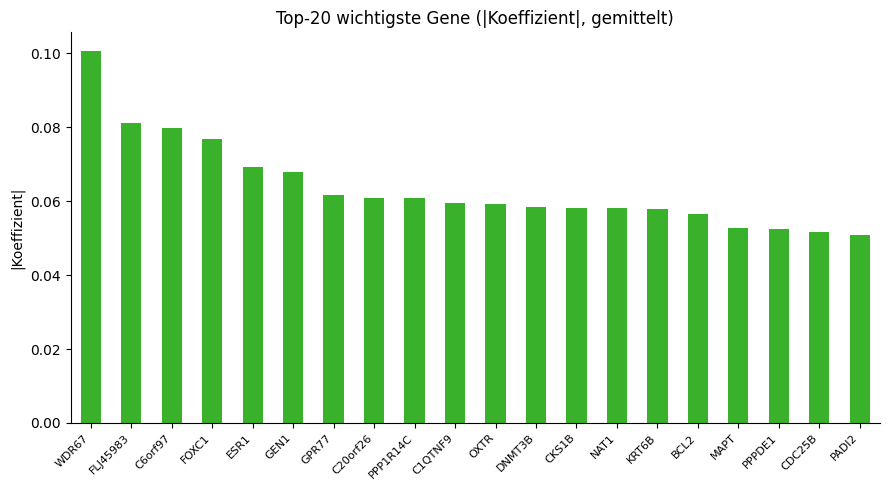

In [48]:
if hasattr(best_model, "coef_"):
    # Logistic Regression: mittlerer |Koeffizient| über alle Klassen
    coef_mean = np.abs(best_model.coef_).mean(axis=0)
    feat_imp = pd.Series(coef_mean, index=sel_k_cols).sort_values(ascending=False)
    print("Top 15 Gene (|Koeffizient| gemittelt über Klassen):")
    print(feat_imp.head(15))

    fig, ax = plt.subplots(figsize=(9, 5))
    feat_imp.head(20).plot(kind="bar", ax=ax, color="#3AB12A", edgecolor="none")
    ax.set_title("Top-20 wichtigste Gene (|Koeffizient|, gemittelt)")
    ax.set_ylabel("|Koeffizient|")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    sns.despine()
    plt.tight_layout()
    plt.savefig("feature_importance_v2.png", dpi=150)
    plt.show()

## 9) Dimensionsreduktion & Visualisierung

PCA Varianzanteil (2 Komponenten): 0.554


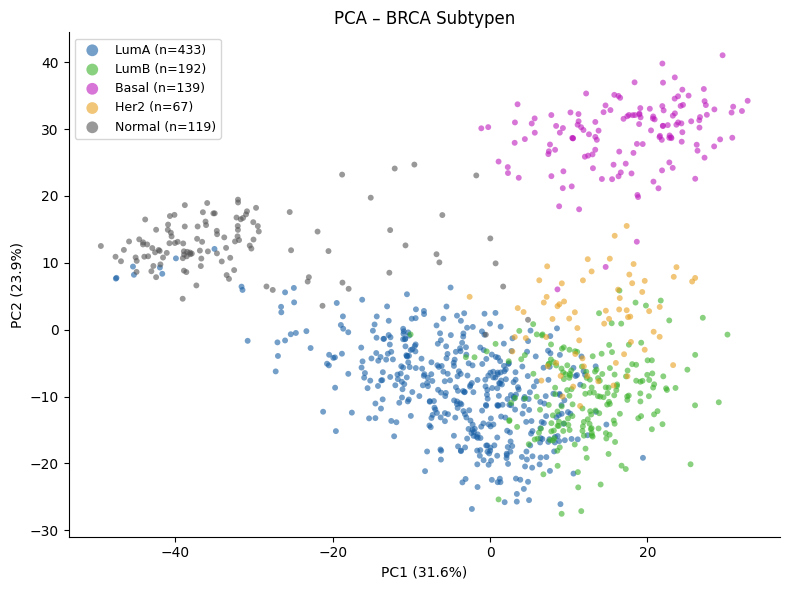

In [50]:
# Gesamten (gesäuberten) Datensatz für Visualisierung
X_all = scaler.transform(X_selected)
y_all = y.values

# --- PCA ---
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_all)
var_expl = pca.explained_variance_ratio_
print(f"PCA Varianzanteil (2 Komponenten): {var_expl.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 6))
for subtype, color in SUBTYPE_COLORS.items():
    mask = y_all == subtype
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f"{subtype} (n={mask.sum()})",
               color=color, alpha=0.6, s=18, edgecolors="none")
ax.set_xlabel(f"PC1 ({var_expl[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var_expl[1]*100:.1f}%)")
ax.set_title("PCA – BRCA Subtypen")
ax.legend(markerscale=2, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=150)
plt.show()

Berechne UMAP (dauert ~30–60 Sek.)...


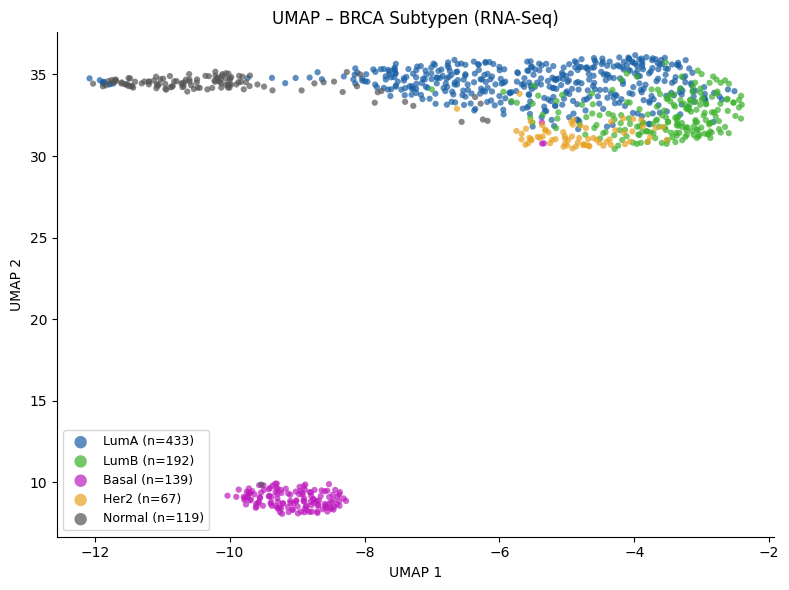

In [51]:
# --- UMAP (viel bessere Cluster-Trennung als PCA) ---
if UMAP_AVAILABLE:
    print("Berechne UMAP (dauert ~30–60 Sek.)...")
    reducer = UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.3,
        metric="euclidean",
        random_state=RANDOM_STATE
    )
    X_umap = reducer.fit_transform(X_all)

    fig, ax = plt.subplots(figsize=(8, 6))
    for subtype, color in SUBTYPE_COLORS.items():
        mask = y_all == subtype
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   label=f"{subtype} (n={mask.sum()})",
                   color=color, alpha=0.7, s=20, edgecolors="none")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title("UMAP – BRCA Subtypen (RNA-Seq)")
    ax.legend(markerscale=2, fontsize=9)
    sns.despine()
    plt.tight_layout()
    plt.savefig("umap_visualization.png", dpi=150)
    plt.show()
else:
    print("UMAP nicht verfügbar. Installiere mit: pip install umap-learn")